> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 6. Feature Engineering

*Scope:* Constructing the representation the model actually learns from — encodings, transformations and derived features.

Chapter 5 made the data *valid*. This chapter makes it *informative* — constructing the representation the
model actually learns from.

The distinction matters because a model can only find structure that its input representation can express.
A linear model given `signup_date` as a string learns nothing; given "months since signup" it learns
immediately. Nothing about the underlying information changed — only whether the model could reach it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")


def canonical_gender(s):
    return s.str.strip().str.lower().replace({"male": "m", "female": "f"})


DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def preprocess(df):
    """Chapter 5's knowledge-free repairs, reused here."""
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = canonical_gender(out["gender"])
    out["signup_date"] = pd.to_datetime(out["signup_date"])
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


customers = preprocess(pd.read_csv("data/customers.csv"))
train, test = train_test_split(customers, test_size=0.2,
                               stratify=customers["churned"], random_state=RANDOM_STATE)
print("train", train.shape, " test", test.shape)

train (800, 14)  test (200, 14)


### 6.1 What Feature Engineering Is and Why It Still Matters

Feature engineering is constructing input variables that make the relationship a model is looking for
easier to express. Three things it does:

| Purpose | Example |
|---|---|
| **Make the implicit explicit** | `signup_date` → months since signup (6.5) |
| **Match the model's hypothesis space** | Add $x^2$ so a linear model can fit a curve (6.4) |
| **Encode what the model cannot read** | `city` → numbers a model can consume (6.2) |

The clearest demonstration is a relationship a linear model provably cannot represent, made trivial by one
constructed column.

In [2]:
# XOR: the class is 1 when exactly ONE of the two features is above its midpoint.
n = 600
a = rng.uniform(0, 10, n)
b = rng.uniform(0, 10, n)
y_xor = ((a > 5) ^ (b > 5)).astype(int)

raw = np.column_stack([a, b])
engineered = np.column_stack([a, b, (a - 5) * (b - 5)])   # one extra column: the interaction

for name, X_ in (("a, b", raw), ("a, b, (a-5)(b-5)", engineered)):
    score = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()),
                            X_, y_xor, cv=5, scoring="roc_auc").mean()
    print(f"logistic regression on [{name:<16}] mean CV AUC {score:.3f}")

logistic regression on [a, b            ] mean CV AUC 0.463


logistic regression on [a, b, (a-5)(b-5)] mean CV AUC 1.000


0.5 is the score of a coin flip (8.5). A linear model computes a weighted **sum** of its inputs, so its
decision boundary is a single straight line — and no straight line separates the two diagonal corners of
an XOR from the other two. The relationship is not merely hard to find, it is **unrepresentable**: no
amount of data, no tuning, no `max_iter` fixes it.

One product column makes the same model perfect, because the sign of $(a-5)(b-5)$ is exactly the answer.

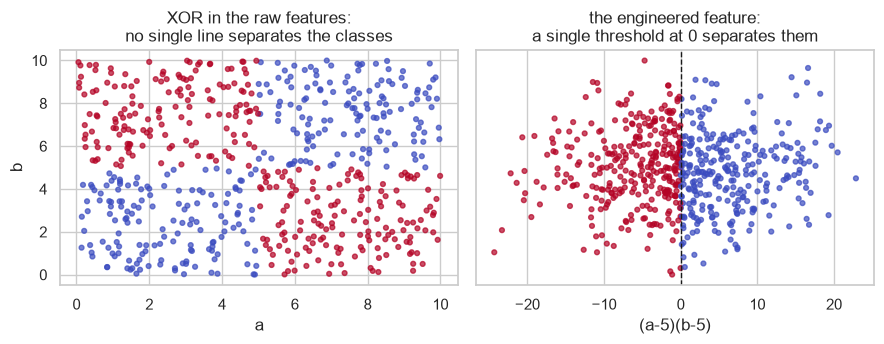

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(a, b, c=y_xor, cmap="coolwarm", s=12, alpha=0.7)
axes[0].set_title("XOR in the raw features:\nno single line separates the classes")
axes[0].set_xlabel("a"); axes[0].set_ylabel("b")

axes[1].scatter((a - 5) * (b - 5), rng.normal(0, 0.4, n), c=y_xor, cmap="coolwarm", s=12, alpha=0.7)
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_title("the engineered feature:\na single threshold at 0 separates them")
axes[1].set_xlabel("(a-5)(b-5)"); axes[1].set_yticks([])

fig.tight_layout()
plt.show()

**Do tree models need this?** Much less. A tree splits on one feature at a time and can stack splits, so
two levels of depth reproduce XOR exactly:

In [4]:
from sklearn.ensemble import RandomForestClassifier

for name, X_ in (("a, b", raw), ("a, b, (a-5)(b-5)", engineered)):
    score = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
                            X_, y_xor, cv=5, scoring="roc_auc").mean()
    print(f"random forest on [{name:<16}] mean CV AUC {score:.3f}")

random forest on [a, b            ] mean CV AUC 1.000


random forest on [a, b, (a-5)(b-5)] mean CV AUC 1.000


The forest solves the raw problem that defeated the linear model completely — that is what "trees need less
feature engineering" means, and it is why Chapters 17–19 are so effective on tabular data with little
preparation. The general shape of the trade:

| | Benefits most from feature engineering |
|---|---|
| Linear and logistic regression (Ch. 11–13) | **Enormously** — it is the only way to express non-linearity |
| k-NN, SVM with a linear kernel (Ch. 14, 16) | Substantially |
| SVM with an RBF kernel (16.5) | Moderately — the kernel supplies some of it |
| Trees and ensembles (Ch. 17–19) | Least — they construct interactions by splitting |

### 6.2 Encoding Categorical Variables

Models consume numbers. Categories must become numbers without inventing an order that is not there
(4.1).

| Encoder | Produces | Use when | Danger |
|---|---|---|---|
| **One-hot** | One binary column per level | Nominal, low cardinality | Explodes with many levels |
| **Ordinal** | One integer column | Genuinely ordered levels | Invents order if misapplied |
| **Target / mean** | The mean target per level | High cardinality, tree models | **Leaks the target** unless done inside CV folds |
| **Frequency / count** | How often the level occurs | High cardinality | Collides levels with equal counts |
| **Hashing** | Fixed-width hashed columns | Very high or unbounded cardinality | Collisions; unreadable |
| **Drop** | Nothing | Identifiers (4.1) | — |

#### 6.2.1 One-hot encoding

In [5]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(train[["plan"]])

print("levels learned:", list(ohe.categories_[0]))
print("output shape  :", encoded.shape)
print(pd.DataFrame(encoded, columns=ohe.get_feature_names_out()).head(3))

levels learned: ['Basic', 'Premium', 'Standard']
output shape  : (800, 3)
   plan_Basic  plan_Premium  plan_Standard
0         0.0           0.0            1.0
1         1.0           0.0            0.0
2         0.0           0.0            1.0


**`handle_unknown` is the setting that decides whether your model survives contact with production.** A
city that never appeared in training will otherwise raise an exception at inference time (3.9.3, 4.9.3).

In [6]:
unseen = pd.DataFrame({"plan": ["Basic", "Enterprise"]})   # "Enterprise" launched after training

lenient = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train[["plan"]])
strict = OneHotEncoder(sparse_output=False, handle_unknown="error").fit(train[["plan"]])

print("ignore ->\n", lenient.transform(unseen))   # unknown row becomes all-zeros
try:
    strict.transform(unseen)
except ValueError as e:
    print("error  ->", str(e)[:75])

ignore ->
 [[1. 0. 0.]
 [0. 0. 0.]]
error  -> Found unknown categories ['Enterprise'] in column 0 during transform


The all-zeros row is a deliberate, sane fallback: "none of the levels I know". It is not free — the model
has genuinely lost information about that row — but it degrades rather than crashes, and it can be detected
by monitoring (24.9).

**The dummy-variable trap.** With an intercept, $k$ one-hot columns are perfectly collinear: knowing $k-1$
of them determines the last. For a plain linear model this makes $X^\top X$ singular (2.4.1). `drop="first"`
removes one column, and the dropped level becomes the baseline the others are measured against.

In [7]:
full = OneHotEncoder(sparse_output=False).fit_transform(train[["plan"]])
dropped = OneHotEncoder(sparse_output=False, drop="first").fit_transform(train[["plan"]])

with_intercept = np.column_stack([np.ones(len(full)), full])
print("columns, full one-hot   :", full.shape[1], "-> rank with intercept:",
      np.linalg.matrix_rank(with_intercept), "of", with_intercept.shape[1], "<- rank deficient")
print("columns, drop='first'   :", dropped.shape[1], "-> rank with intercept:",
      np.linalg.matrix_rank(np.column_stack([np.ones(len(dropped)), dropped])),
      "of", dropped.shape[1] + 1, "<- full rank")

columns, full one-hot   : 3 -> rank with intercept: 3 of 4 <- rank deficient
columns, drop='first'   : 2 -> rank with intercept: 3 of 3 <- full rank


| Model | Drop a level? |
|---|---|
| Plain `LinearRegression` with intercept | **Yes** — otherwise rank-deficient |
| Ridge / lasso / logistic with regularization | No — the penalty resolves the ambiguity, and dropping distorts which level is penalized |
| Trees and ensembles | No — no intercept, no collinearity problem |

#### 6.2.2 Ordinal encoding

Only for genuinely ordered categories, and **specify the order explicitly** — the default is alphabetical,
which is almost never the meaning.

In [8]:
from sklearn.preprocessing import OrdinalEncoder

alphabetical = OrdinalEncoder().fit(train[["plan"]])
correct = OrdinalEncoder(categories=[["Basic", "Standard", "Premium"]]).fit(train[["plan"]])

print("default (alphabetical):", dict(zip(alphabetical.categories_[0], range(3))))
print("explicit (meaningful) :", dict(zip(correct.categories_[0], range(3))))

default (alphabetical): {'Basic': 0, 'Premium': 1, 'Standard': 2}
explicit (meaningful) : {'Basic': 0, 'Standard': 1, 'Premium': 2}


Alphabetically, Basic=0, Premium=1, Standard=2 — which tells a model that Premium sits *between* Basic and
Standard. That is not a rounding error; it is a false statement about the world, and a linear model will
act on it.

#### 6.2.3 High cardinality, and target encoding

One-hot on a high-cardinality column produces a very wide, very sparse matrix. **Target encoding** replaces
each level with the mean target for that level — one column regardless of cardinality.

It is also the single most reliable way to leak the target, so it needs care.

In [9]:
city_means = train.groupby("city")["churned"].mean()
print("target encoding of city, learned on TRAIN only:")
print(city_means.round(3).to_string())

target encoding of city, learned on TRAIN only:


city
Bengaluru    0.155
Chennai      0.129
Delhi        0.234
Hyderabad    0.146
Jaipur       0.086
Kolkata      0.150
Mumbai       0.127
Pune         0.103


**Common mistake — target encoding computed on the full dataset, or without cross-fitting.** Both leak.
The full-dataset version is obvious (the test rows contributed to the means). The subtler one: even
computed on training data alone, a row's own target contributes to the mean it is then encoded with, so
the feature is partly *made of* the answer. On a high-cardinality column this is devastating — with one row
per level, the encoding **is** the target.

In [10]:
# An id-like column with ~250 levels and no real signal at all.
noise_train = train.copy()
noise_train["fake_id"] = rng.integers(0, 250, len(noise_train))

naive_map = noise_train.groupby("fake_id")["churned"].mean()
noise_train["te_naive"] = noise_train["fake_id"].map(naive_map)

auc_naive = cross_val_score(LogisticRegression(), noise_train[["te_naive"]],
                            noise_train["churned"], cv=5, scoring="roc_auc").mean()
print(f"CV AUC from a target-encoded RANDOM column: {auc_naive:.3f}  <- pure leakage")

CV AUC from a target-encoded RANDOM column: 0.901  <- pure leakage


A column of random integers now looks predictive, because each row's encoded value was built from its own
label. The fix is **cross-fitting**: encode each fold using means computed from the *other* folds only.
scikit-learn's `TargetEncoder` does this internally.

In [11]:
from sklearn.preprocessing import TargetEncoder

te = TargetEncoder(random_state=RANDOM_STATE)
encoded_cv = te.fit_transform(noise_train[["fake_id"]], noise_train["churned"])

auc_cross_fitted = cross_val_score(LogisticRegression(), encoded_cv,
                                   noise_train["churned"], cv=5, scoring="roc_auc").mean()
print(f"CV AUC with cross-fitted TargetEncoder    : {auc_cross_fitted:.3f}  <- correctly ~0.5")

CV AUC with cross-fitted TargetEncoder    : 0.496  <- correctly ~0.5


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Cross-fitting restores the honest answer: a random column carries no signal. **`fit_transform` and
`transform` deliberately behave differently on `TargetEncoder`** — the first cross-fits (for training), the
second uses the full-data means (for inference). That asymmetry is the whole point, and it is why the
encoder must live inside a `Pipeline` rather than being applied by hand.

**Frequency encoding** is a simpler alternative that cannot leak, because it never touches the target.

In [12]:
freq = train["city"].value_counts(normalize=True)
print("frequency encoding of city:")
print(freq.round(3).to_string())

frequency encoding of city:
city
Kolkata      0.216
Bengaluru    0.201
Pune         0.146
Hyderabad    0.129
Chennai      0.106
Mumbai       0.099
Delhi        0.059
Jaipur       0.044


### 6.3 Binning and Discretization

Binning converts a continuous feature into ordered categories. It trades resolution for the ability to
express a non-linear, non-monotonic relationship in a linear model.

| Strategy | Bin edges from | Good when |
|---|---|---|
| `uniform` | Equal-width ranges | The variable is roughly uniform |
| `quantile` | Equal-count buckets | Skewed data; guarantees populated bins |
| `kmeans` | 1-D clustering | Natural groupings exist |
| Manual | Domain knowledge | The thresholds *mean* something ("first year") |

In [13]:
from sklearn.preprocessing import KBinsDiscretizer

tenure = train[["tenure_months"]]

for strategy in ("uniform", "quantile"):
    binner = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy=strategy,
                              quantile_method="averaged_inverted_cdf").fit(tenure)
    edges = binner.bin_edges_[0].round(1)
    counts = np.bincount(binner.transform(tenure).ravel().astype(int))
    print(f"{strategy:<9} edges {edges}  counts {counts}")

uniform   edges [ 1.  18.8 36.5 54.2 72. ]  counts [206 203 188 203]
quantile  edges [ 1. 18. 35. 55. 72.]  counts [197 197 203 203]


Manual bins are usually the ones worth having, because their edges carry meaning that a model cannot
discover and a human can explain:

In [14]:
tenure_band = pd.cut(train["tenure_months"], bins=[0, 6, 12, 24, 60, np.inf],
                     labels=["0-6m", "6-12m", "1-2y", "2-5y", "5y+"])

band_summary = (pd.DataFrame({"band": tenure_band, "churned": train["churned"]})
                .groupby("band", observed=True)["churned"]
                .agg(["count", "mean"]).round(3))
print(band_summary)

       count   mean
band               
0-6m      57  0.491
6-12m     73  0.274
1-2y     143  0.175
2-5y     394  0.091
5y+      133  0.030


The churn rate falls monotonically from **49% in the first six months to 3% after five years**. That is
readable by a human, usable directly in a business rule, and — being monotonic — something a linear model
could have captured from the raw column anyway.

**Common mistake — binning by reflex.** Binning always discards information. It helps when the
relationship is genuinely non-monotonic or when interpretability matters more than accuracy; it hurts when
the relationship was fine as it was.

In [15]:
X_continuous = train[["tenure_months"]]
X_binned = KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile",
                            quantile_method="averaged_inverted_cdf").fit_transform(X_continuous)

for name, X_ in (("continuous", X_continuous), ("4 quantile bins", X_binned)):
    score = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()),
                            X_, train["churned"], cv=5, scoring="roc_auc").mean()
    print(f"logistic regression on {name:<16} CV AUC {score:.3f}")

logistic regression on continuous       CV AUC 0.766


logistic regression on 4 quantile bins  CV AUC 0.747


Binning costs AUC here: the relationship was monotonic, so the continuous column was already in the form a
linear model wanted, and the bins only threw away resolution.

### 6.4 Interaction and Polynomial Features

An **interaction** is a product of two features. It lets a model express "the effect of A depends on B",
which no additive model can otherwise say.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

sample = train[["tenure_months", "support_tickets"]].head(3)

poly = PolynomialFeatures(degree=2, include_bias=False)
expanded = poly.fit_transform(sample)

print("input columns :", list(sample.columns))
print("output columns:", list(poly.get_feature_names_out()))
print(pd.DataFrame(expanded, columns=poly.get_feature_names_out()).round(1))

input columns : ['tenure_months', 'support_tickets']
output columns: ['tenure_months', 'support_tickets', 'tenure_months^2', 'tenure_months support_tickets', 'support_tickets^2']
   tenure_months  support_tickets  tenure_months^2  tenure_months support_tickets  support_tickets^2
0           67.0              3.0           4489.0                          201.0                9.0
1           34.0              1.0           1156.0                           34.0                1.0
2           10.0              1.0            100.0                           10.0                1.0


`interaction_only=True` keeps the cross-products and drops the squares, which is often what you actually
want. The reason to be selective is combinatorial: the number of degree-2 terms grows as $O(p^2)$, and
degree-3 as $O(p^3)$.

In [17]:
for p in (5, 10, 30, 100):
    d2 = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((2, p))).n_output_features_
    d3 = PolynomialFeatures(degree=3, include_bias=False).fit(np.zeros((2, p))).n_output_features_
    print(f"{p:>4} features -> degree 2: {d2:>7,}   degree 3: {d3:>9,}")

   5 features -> degree 2:      20   degree 3:        55


  10 features -> degree 2:      65   degree 3:       285
  30 features -> degree 2:     495   degree 3:     5,455
 100 features -> degree 2:   5,150   degree 3:   176,850


Thirty features become 5,455 at degree 3. That is not merely slow — it is 7.1's curse of dimensionality
arriving by choice, and it will overfit ferociously without heavy regularization (Chapter 12).

Polynomial features let a *linear* model fit a curve, which is 11.8's subject:

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x_curve = np.linspace(-3, 3, 200).reshape(-1, 1)
y_curve = 0.5 * x_curve.ravel() ** 2 - x_curve.ravel() + rng.normal(0, 0.4, 200)

linear = LinearRegression().fit(x_curve, y_curve)
quadratic = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(x_curve, y_curve)

print(f"straight line     R^2 {r2_score(y_curve, linear.predict(x_curve)):.3f}")
print(f"with x^2 added    R^2 {r2_score(y_curve, quadratic.predict(x_curve)):.3f}")

straight line     R^2 0.586
with x^2 added    R^2 0.964


### 6.5 Datetime and Cyclical Features

A raw timestamp is nearly useless as a feature: it is almost unique per row (4.1), and its numeric value —
seconds since 1970 — encodes calendar structure in a form no model can exploit. Decompose it.

| Derived feature | Captures |
|---|---|
| Year, month, day | Level and long-term trend |
| Day of week | Weekly rhythm |
| Hour | Daily rhythm |
| Is weekend / holiday | Behavioural regimes |
| **Elapsed time since an event** | Age, tenure, recency — usually the most predictive of all |

In [19]:
REFERENCE_DATE = pd.Timestamp("2024-01-01")   # a fixed "now", so the feature is reproducible

dates = train["signup_date"]
date_features = pd.DataFrame({
    "year": dates.dt.year,
    "month": dates.dt.month,
    "day_of_week": dates.dt.dayofweek,
    "quarter": dates.dt.quarter,
    "is_weekend": dates.dt.dayofweek.isin([5, 6]).astype(int),
    "days_since_signup": (REFERENCE_DATE - dates).dt.days,
})
print(date_features.head(3))
print("\ndays_since_signup range:", date_features["days_since_signup"].min(),
      "-", date_features["days_since_signup"].max())

     year  month  day_of_week  quarter  is_weekend  days_since_signup
28   2022      5            5        2           1                604
633  2019      9            6        3           1               1562
650  2021      6            3        2           0                928

days_since_signup range: 27 - 1826


**Common mistake — using `datetime.now()` to build an elapsed-time feature.** The feature then depends on
*when the code ran*, so the notebook is unreproducible and the training and serving values are computed
against different reference points. Fix a reference date, or compute the elapsed time relative to another
column in the same row.

#### 6.5.1 Cyclical encoding

Month 12 and month 1 are adjacent in reality and eleven units apart as integers. The standard fix maps the
cycle onto a circle with sine and cosine, so that the distance between December and January is small:

$$x_{\sin} = \sin\!\left(\frac{2\pi t}{T}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi t}{T}\right)$$

In [20]:
months = np.arange(1, 13)
m_sin = np.sin(2 * np.pi * months / 12)
m_cos = np.cos(2 * np.pi * months / 12)

def distance(i, j, s, c):
    return np.hypot(s[i - 1] - s[j - 1], c[i - 1] - c[j - 1])

print(f"raw integer distance,  Dec to Jan: {abs(12 - 1)}")
print(f"raw integer distance,  Jan to Feb: {abs(1 - 2)}")
print(f"cyclical distance,     Dec to Jan: {distance(12, 1, m_sin, m_cos):.3f}")
print(f"cyclical distance,     Jan to Feb: {distance(1, 2, m_sin, m_cos):.3f}   <- now equal, as it should be")

raw integer distance,  Dec to Jan: 11
raw integer distance,  Jan to Feb: 1
cyclical distance,     Dec to Jan: 0.518
cyclical distance,     Jan to Feb: 0.518   <- now equal, as it should be


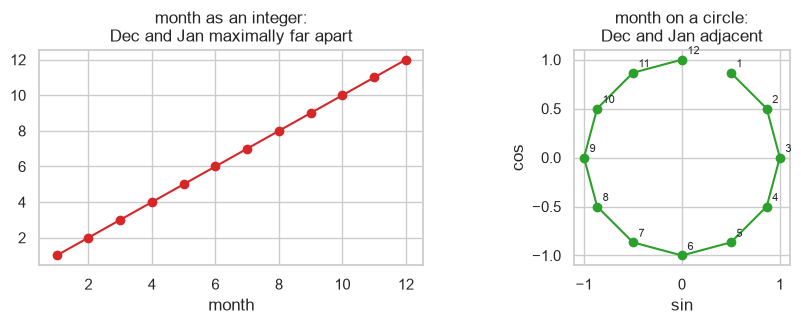

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(months, months, "o-", color="tab:red")
axes[0].set_title("month as an integer:\nDec and Jan maximally far apart")
axes[0].set_xlabel("month")

axes[1].plot(m_sin, m_cos, "o-", color="tab:green")
for m in months:
    axes[1].annotate(str(m), (m_sin[m - 1], m_cos[m - 1]), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
axes[1].set_title("month on a circle:\nDec and Jan adjacent")
axes[1].set_xlabel("sin"); axes[1].set_ylabel("cos")
axes[1].set_aspect("equal")

fig.tight_layout()
plt.show()

Both columns are needed. Sine alone is ambiguous — it takes the same value at two points in the cycle — and
only the pair identifies a position uniquely.

### 6.6 Text as Features

Text has to become a fixed-width numeric vector. The two standard approaches both build a vocabulary from
the training data and count.

| Vectorizer | Value in each cell | Notes |
|---|---|---|
| `CountVectorizer` | Raw term count | Frequent, uninformative words dominate |
| `TfidfVectorizer` | Count × inverse document frequency | Down-weights words common across all documents |

**TF-IDF** multiplies how often a term appears in a document by how *rare* it is across the corpus, so
"the" scores near zero while a distinctive term scores highly.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

docs = [
    "the service was slow and the support was unhelpful",
    "the price increased and the service stayed slow",
    "excellent support, fast and reliable service",
    "the price is fair and the support is excellent",
]

count_vec = CountVectorizer()
counts = count_vec.fit_transform(docs)
print("vocabulary size:", len(count_vec.vocabulary_))
print("matrix shape   :", counts.shape, "-> one row per document, one column per term")
print(pd.DataFrame(counts.toarray(), columns=count_vec.get_feature_names_out()).iloc[:, :8])

vocabulary size: 15
matrix shape   : (4, 15) -> one row per document, one column per term
   and  excellent  fair  fast  increased  is  price  reliable
0    1          0     0     0          0   0      0         0
1    1          0     0     0          1   0      1         0
2    1          1     0     1          0   0      0         1
3    1          1     1     0          0   2      1         0


In [23]:
tfidf = TfidfVectorizer()
weights = tfidf.fit_transform(docs)

frame = pd.DataFrame(weights.toarray(), columns=tfidf.get_feature_names_out())
print("highest-weighted term in each document:")
for i in range(len(docs)):
    top = frame.iloc[i].idxmax()
    print(f"  doc {i}: '{top}' ({frame.iloc[i].max():.3f})   |  'the' scores {frame.iloc[i]['the']:.3f}")

highest-weighted term in each document:
  doc 0: 'was' (0.693)   |  'the' scores 0.442
  doc 1: 'the' (0.542)   |  'the' scores 0.542
  doc 2: 'fast' (0.519)   |  'the' scores 0.000
  doc 3: 'is' (0.684)   |  'the' scores 0.437


Read the two columns together. In document 2 — the only one without the word — `the` scores exactly
**0.000**, and a distinctive term wins. In documents 0 and 3, `the` appears twice and still loses to a
rarer term. Document 1 is the honest exception: `the` appears twice in a short document and does win,
because IDF *down-weights* common terms rather than eliminating them.

The lesson is that TF-IDF reduces the dominance of common words without anyone supplying a stop-word list,
but it does not remove them. For a real corpus, `stop_words="english"` or a `max_df` threshold still earns
its place.

Two settings that matter more than any other:

| Setting | Does | Why |
|---|---|---|
| `ngram_range=(1, 2)` | Also counts adjacent word pairs | Captures "not good", which unigrams cannot |
| `min_df`, `max_df` | Drops terms that are too rare or too common | Controls vocabulary size and overfitting |

In [24]:
unigram = TfidfVectorizer().fit(docs)
bigram = TfidfVectorizer(ngram_range=(1, 2)).fit(docs)

print("unigrams only      :", len(unigram.get_feature_names_out()), "features")
print("unigrams + bigrams :", len(bigram.get_feature_names_out()), "features")
print("sample bigrams:", [t for t in bigram.get_feature_names_out() if " " in t][:5])

unigrams only      : 15 features
unigrams + bigrams : 38 features
sample bigrams: ['and reliable', 'and the', 'excellent support', 'fair and', 'fast and']


The vocabulary is built by `fit` and is therefore **learned from training data** — a word that only appears
at inference time is silently ignored, exactly like an unseen category (6.2.1). 15.7 uses this machinery
for a full text-classification run.

### 6.7 Domain-Driven Features

The features that win are usually the ones that encode something a person knows about the problem, not
the ones a library generates. Four patterns that transfer across domains:

| Pattern | Form | Example here |
|---|---|---|
| **Ratio** | `a / b` | Charges per month of tenure |
| **Difference / delta** | `a - b` | Actual spend minus expected spend for the plan |
| **Rate** | `count / exposure` | Support tickets per month of tenure |
| **Recency / frequency** | Time since last event, events per period | Days since last login |

In [25]:
def add_domain_features(df):
    out = df.copy()
    out["tickets_per_month"] = out["support_tickets"] / out["tenure_months"].clip(lower=1)
    out["charges_per_tenure"] = out["total_charges"] / out["tenure_months"].clip(lower=1)
    out["spend_vs_plan"] = out["monthly_charges"] - out.groupby("plan")["monthly_charges"].transform("mean")
    out["login_recency_ratio"] = out["last_login_days"] / out["tenure_months"].clip(lower=1)
    return out


train_fe = add_domain_features(train)
new_cols = ["tickets_per_month", "charges_per_tenure", "spend_vs_plan", "login_recency_ratio"]
print(train_fe[new_cols].describe().round(3).T[["mean", "std", "min", "max"]])

                       mean     std     min     max
tickets_per_month     0.109   0.337   0.000   4.000
charges_per_tenure   40.198  17.623   0.000  89.710
spend_vs_plan        -0.000   7.691 -17.781  24.655
login_recency_ratio   0.833   2.422   0.000  45.000


Note `.clip(lower=1)` on every denominator. Division by zero is the most common way an engineered feature
produces `inf` or `NaN`, and it will crash a scaler downstream rather than fail visibly here.

Do the engineered features earn their place? Measure, do not assume:

In [26]:
from sklearn.impute import SimpleImputer

base_cols = ["age", "tenure_months", "monthly_charges", "support_tickets",
             "last_login_days", "satisfaction_score"]

pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                     LogisticRegression(max_iter=2000))

for name, cols in (("base features", base_cols), ("base + domain", base_cols + new_cols)):
    score = cross_val_score(pipe, train_fe[cols], train_fe["churned"],
                            cv=5, scoring="roc_auc").mean()
    print(f"{name:<16} ({len(cols)} cols) CV AUC {score:.3f}")

base features    (6 cols) CV AUC 0.820


base + domain    (10 cols) CV AUC 0.815


They do not — the four ratios cost 0.005 AUC. That is the expected outcome more often than the folklore
admits, and reporting it is the point of measuring. `tickets_per_month` and `charges_per_tenure` are
largely re-expressions of columns the model already has, so they add parameters without adding information
(9.1). Keep a feature when it earns its place on a validation score, not when it sounds insightful.

**A warning about `spend_vs_plan`.** It uses `groupby("plan").transform("mean")` — a statistic computed
**from the data**. Written as above it computes the plan means from whatever frame it is handed, so
applying it to the test set would compute test-set means. That is a leak of exactly the shape 5.1 warns
about, and it is invisible because the function looks purely arithmetic.

In [27]:
plan_means_train = train["plan"].map(train.groupby("plan")["monthly_charges"].mean())
plan_means_test_wrong = test["plan"].map(test.groupby("plan")["monthly_charges"].mean())
plan_means_test_right = test["plan"].map(train.groupby("plan")["monthly_charges"].mean())

print("plan means from TRAIN:", train.groupby("plan")["monthly_charges"].mean().round(3).to_dict())
print("plan means from TEST :", test.groupby("plan")["monthly_charges"].mean().round(3).to_dict())
print("\nmax difference in the engineered feature:",
      float((plan_means_test_wrong - plan_means_test_right).abs().max().round(4)))

plan means from TRAIN: {'Basic': 25.65, 'Premium': 65.055, 'Standard': 45.681}
plan means from TEST : {'Basic': 25.595, 'Premium': 64.179, 'Standard': 45.871}

max difference in the engineered feature: 0.8757


The correct version maps the **training** means onto the test rows. Any feature built from a group
statistic, a global mean, a rank or a quantile has this property, and the only reliable defence is to
implement it as a fitted transformer inside a `Pipeline` (23.3) rather than as a function over a DataFrame.

### 6.8 Fit on Train Only

Every learned transformation in Chapters 5 and 6 obeys one rule, and this section states it once for all of
them.

**A transformation is "learned" if changing the data would change the transformation.** That is the test.

| Operation | Learned? | Why |
|---|---|---|
| `x * 2`, `log(x)`, `a / b` | No | Depends only on the row |
| Extracting `month` from a date | No | Depends only on the row |
| Domain clipping to `[16, 100]` (5.3) | No | The bounds come from knowledge, not data |
| Imputing with the median | **Yes** | The median is estimated from data |
| Standard scaling | **Yes** | Mean and standard deviation are estimated |
| One-hot encoding | **Yes** | The level list is learned |
| Target encoding | **Yes**, doubly | Learns from the features *and* the target |
| Binning by quantile | **Yes** | The edges are quantiles of the data |
| Binning at fixed edges | No | The edges were chosen by a human |
| Feature selection (7.2) | **Yes** | The chosen subset depends on the data |

Everything in the "yes" column must be `fit` on training data and `transform`-ed onto everything else.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
categorical = ["gender", "city", "plan"]

feature_pipeline = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                          StandardScaler()), numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])

X_train = feature_pipeline.fit_transform(train)   # fit + transform
X_test = feature_pipeline.transform(test)          # transform ONLY

print("train:", X_train.shape)
print("test :", X_test.shape)
print("\nlearned category levels for 'city':",
      list(feature_pipeline.named_transformers_["cat"][-1].categories_[1]))

train: (800, 23)
test : (200, 23)

learned category levels for 'city': ['Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']


Every learned parameter — seven medians, seven means and standard deviations, three category lists — now
lives inside one object. `transform` cannot accidentally re-learn them, because `transform` has no code
path that fits anything. That is what "structural rather than remembered" means.

### 6.9 In Practice

#### 6.9.1 A worked case: how much does feature engineering actually buy?

The honest way to answer is a ladder — the same model, the same split, the same metric, adding one layer of
representation at a time.

In [29]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}


def score_features(name, frame, columns, transformer):
    pipe = make_pipeline(transformer, LogisticRegression(max_iter=3000))
    auc = cross_val_score(pipe, frame[columns], frame["churned"], cv=cv, scoring="roc_auc").mean()
    results[name] = auc
    print(f"{name:<42} {len(columns):>3} cols   CV AUC {auc:.4f}")
    return auc


numeric_only = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
score_features("1. raw numeric features", train, base_cols, numeric_only)

1. raw numeric features                      6 cols   CV AUC 0.8140


np.float64(0.8140306588576978)

In [30]:
# 2. add the categorical columns, properly encoded
full_transformer = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), base_cols),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])
score_features("2. + one-hot categoricals", train, base_cols + categorical, full_transformer)

2. + one-hot categoricals                    9 cols   CV AUC 0.8023


np.float64(0.8022542146312379)

In [31]:
# 3. add the date decomposition (6.5)
train_dates = train.assign(
    days_since_signup=(REFERENCE_DATE - train["signup_date"]).dt.days,
    signup_month_sin=np.sin(2 * np.pi * train["signup_date"].dt.month / 12),
    signup_month_cos=np.cos(2 * np.pi * train["signup_date"].dt.month / 12),
)
date_cols = ["days_since_signup", "signup_month_sin", "signup_month_cos"]

date_transformer = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), base_cols + date_cols),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])
score_features("3. + datetime features", train_dates, base_cols + date_cols + categorical,
               date_transformer)

3. + datetime features                      12 cols   CV AUC 0.7930


np.float64(0.7929988555821625)

In [32]:
# 4. add the domain ratios (6.7)
train_all = add_domain_features(train_dates)
all_numeric = base_cols + date_cols + new_cols

all_transformer = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), all_numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])
score_features("4. + domain ratio features", train_all, all_numeric + categorical, all_transformer)

4. + domain ratio features                  16 cols   CV AUC 0.7853


np.float64(0.785284613831107)

In [33]:
# 5. add pairwise interactions among the strongest few (6.4)
from sklearn.preprocessing import PolynomialFeatures

strong = ["tenure_months", "support_tickets", "satisfaction_score", "last_login_days"]

interaction_transformer = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), all_numeric),
    ("inter", make_pipeline(SimpleImputer(strategy="median"),
                            PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
                            StandardScaler()), strong),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])
score_features("5. + pairwise interactions", train_all, all_numeric + categorical,
               interaction_transformer)

best = max(results, key=results.get)
print(f"\nbest rung: {best}  ({results[best]:.4f})")
print(f"change from rung 1 to rung 5: {results['5. + pairwise interactions'] - results['1. raw numeric features']:+.4f} AUC")

5. + pairwise interactions                  16 cols   CV AUC 0.7808

best rung: 1. raw numeric features  (0.8140)
change from rung 1 to rung 5: -0.0332 AUC


**Every single rung made it worse.** 0.814 down to 0.781, monotonically, while the column count more than
doubled. That is the real result on this dataset, and burying it would teach the wrong lesson.

Why it happens is exactly what Chapter 9 is about. Each added column gives the model another parameter to
fit; when the column carries no signal, the parameter fits noise instead, and the cross-validated score
pays for it. `city` has eight levels and 4.5 showed none of them differ from any other beyond sampling
noise; the signup month is unrelated to churn; the domain ratios re-express columns already present (6.7).
Eight hundred rows and a fixed regularization strength (`C=1.0`) cannot absorb seventeen extra parameters
for free.

Three conclusions, and the third is the one worth carrying:

1. **Feature engineering is not additive.** Features are hypotheses, and most hypotheses are wrong. This
   chapter's XOR example (6.1) and polynomial fit (6.4) show the enormous gains available *when the
   hypothesis is right*; the ladder shows the ordinary case.
2. **The cure for a declining ladder is selection, not more features.** Chapter 7 is next for exactly this
   reason: with a good subset of these seventeen columns, the score recovers. Stronger regularization
   (Chapter 12) is the other route.
3. **Measure every rung.** The version of this analysis that skips the measurement ships all seventeen
   columns, reports 0.78, and never learns that six columns did better. Adding features because they sound
   clever, and never checking, is how pipelines accumulate fifty columns that actively hurt.

Note also what this comparison holds fixed and therefore cannot tell you: one model family, one
regularization strength, one dataset of 800 rows. A random forest, or a tuned `C`, would rank these rungs
differently — 23.5 searches the two together for this reason.

#### 6.9.2 When to reach for which encoding

| Situation | Use | Not |
|---|---|---|
| Nominal, under ~15 levels | One-hot | Ordinal — it invents an order |
| Genuinely ordered levels | Ordinal, with explicit `categories=` | The alphabetical default (6.2.2) |
| Over ~50 levels, tree model | Target encoding **inside** a pipeline | Hand-computed group means (6.2.3) |
| Over ~50 levels, linear model | Frequency encoding, or group rare levels into "other" | One-hot — the matrix explodes |
| Unbounded cardinality (URLs, IDs) | Hashing, or drop | One-hot |
| Level set will grow in production | `handle_unknown="ignore"` | The default `"error"` |
| Plain linear regression with intercept | `drop="first"` | Full one-hot — rank deficient (6.2.1) |
| Regularized or tree model | Full one-hot | `drop="first"` — it distorts the penalty |
| A cyclic quantity (month, hour, angle) | sin/cos pair (6.5.1) | The raw integer |
| A date | Decompose it (6.5) | The raw timestamp |

#### 6.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Unseen category** | Exception at inference, or a silently all-zero row | 6.2.1 |
| **Target-encoding leak** | Excellent offline AUC, near-random in production | 6.2.3 |
| **Group statistic recomputed at inference** | The feature means something different for every batch | 6.7 |
| **`now()` in a feature** | Training and serving compute elapsed time from different reference points | 6.5 |
| **Division by zero** | `inf` or `NaN` reaches a scaler and crashes, or silently propagates | 6.7 |
| **Feature order changes** | Column 3 becomes column 5; the model reads the wrong values | 6.8 |
| **Vocabulary drift** | New product names never appear in the TF-IDF vocabulary | 6.6 |

Two of these deserve the last word because they are silent rather than loud. A **target-encoding leak**
produces a model that looks better than anything else you built and is worthless — the offline score is
literally computed from the answer. And a **group statistic recomputed at inference** changes the meaning
of a feature between training and serving without changing a line of code, so the model receives inputs it
was never fitted on.

Both have the same defence, and it is the same one 5.8.3 arrived at: **the transformation must be a fitted
object that ships with the model** (23.2, 24.8). A feature engineered by a pandas expression is a feature
that exists twice — once in the notebook and once, differently, in production.

In [34]:
# --- 6. Feature Engineering — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.